In [18]:
# Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load central data

print("loading central data...")
X_train_global = np.load("../data/processed/X_train.npy")
X_test_global = np.load("../data/processed/X_test.npy")
y_test_global = np.load("../data/processed/y_test.npy", allow_pickle=True)

print(f"Total Training Data: {len(X_train_global)} samples")

loading central data...
Total Training Data: 1818477 samples


In [6]:
# Create 3 Clients
client_1_data, rest_data = train_test_split(X_train_global, test_size=0.66, random_state=42)
client_2_data, client_3_data = train_test_split(rest_data, test_size=0.5, random_state=42)

print("------Data Distribution------")
print(f"Client 1: {client_1_data.shape} samples")
print(f"Client 2: {client_2_data.shape} samples")
print(f"Client 3: {client_3_data.shape} samples")

------Data Distribution------
Client 1: (618282, 21) samples
Client 2: (600097, 21) samples
Client 3: (600098, 21) samples


In [7]:
# Federated Model (FALCON Model)

def build_falcon_model(input_dim=21):
    input_layer = layers.Input(shape=(input_dim,))

    # Encoder
    encoded = layers.Dense(16, activation='relu')(input_layer)
    encoded = layers.Dense(8, activation='relu')(encoded)

    # Decoder
    decoded = layers.Dense(16, activation='relu')(encoded)
    output_layer = layers.Dense(input_dim, activation='linear')(decoded)

    # Compile
    model = models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mse')
    return model

print("Simulation Environment Ready.")


Simulation Environment Ready.


In [10]:
# global model & client definition

global_model = build_falcon_model()
global_weights = global_model.get_weights()

clients = [client_1_data, client_2_data, client_3_data]
client_names = ['A', 'B', 'C']

In [11]:
# Federated Learning Simulation

ROUNDS = 5     #how many times the server sends out model to learn
EPOCHS_PER_ROUND = 1     #how much work does each client does before reporting back 

# starting training loop
print(f"Starting Federated Fraining for {ROUNDS} Rounds...")

history_f1 = []

for round_num in range(1, ROUNDS + 1):
    print(f"\n---Round {round_num}/{ROUNDS}---")

    local_weights_list = []

    # Phase 1: Distribution & Train
    for i, client_data in enumerate(clients):
        local_model = build_falcon_model()
        local_model.set_weights(global_weights)

        local_model.fit(client_data, client_data,
                        epochs = EPOCHS_PER_ROUND,
                        batch_size = 256,
                        verbose=0)
        
        weights = local_model.get_weights()
        local_weights_list.append(weights)
        print(f" * Client {client_names[i]} finished training.")

    # Phase 2: Aggregation (FedAvg)
    # Math: New_Global = (Weights_A + Weights_B + Weights_C) / 3
    print("Server Aggregating Weights...")
    new_global_weights = []
    for layer_weights_tuple in zip(*local_weights_list):
        averaged_layer = np.mean(np.array(layer_weights_tuple), axis=0)
        new_global_weights.append(averaged_layer)

    global_weights = new_global_weights
    global_model.set_weights(global_weights)

    # Phase 3: Evaluation
    reconstructions = global_model.predict(X_test_global, verbose=0)
    mse = np.mean(np.power(X_test_global - reconstructions, 2), axis=1)

    threshold = 0.1
    y_pred = [1 if e > threshold else 0 for e in mse ]

    y_true_numeric = [0 if label == 'BENIGN' else 1 for label in y_test_global]

    f1 = f1_score(y_true_numeric, y_pred)
    history_f1.append(f1)
    print(f"Global Model F1 Score: {f1:.4f}")

print("\nFederated Training Complete!")
print(f"Final F1 Score: {history_f1[-1]:.4f}")





Starting Federated Fraining for 5 Rounds...

---Round 1/5---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score: 0.6045

---Round 2/5---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score: 0.6075

---Round 3/5---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score: 0.5608

---Round 4/5---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score: 0.5079

---Round 5/5---
 * Client A finished training.
 * Client B finished training.
 * Client C finished training.
Server Aggregating Weights...
Global Model F1 Score: 0.4784

Federated Training Complete!
Final F1 Score: 0.4784


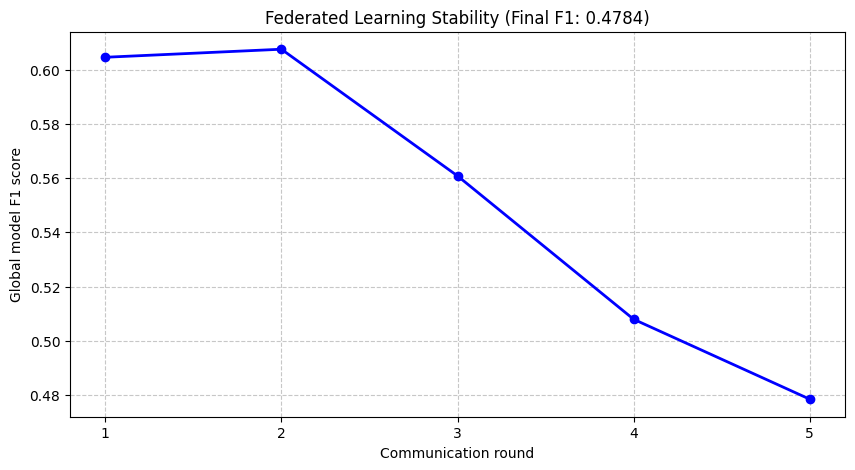

In [14]:
# Visualization

# learning curve
plt.figure(figsize=(10,5))
plt.plot(range(1, ROUNDS + 1), history_f1, marker='o', linestyle='-', color='b', linewidth=2)
plt.title(f"Federated Learning Stability (Final F1: {history_f1[-1]:.4f})")
plt.xlabel("Communication round")
plt.ylabel("Global model F1 score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, ROUNDS + 1))
plt.show()

Generating Federated Confusion Matrix...
------REPORT CARD------
Accuracy: 0.6089
Precision: 0.9015
Recall: 0.3256
F1 Score: 0.4784


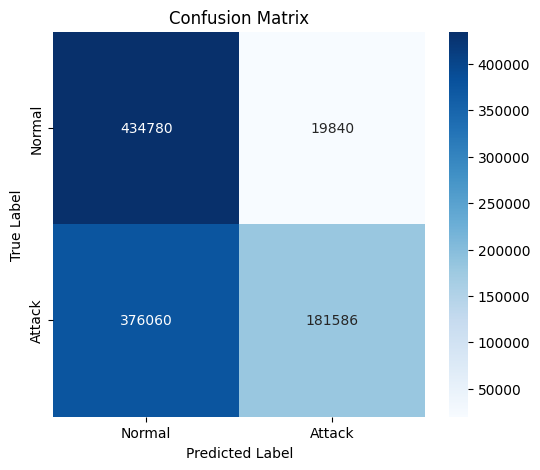

In [ ]:
# Evaluation

global_reconstructions = global_model.predict(X_test_global, verbose=0)
global_mse = np.mean(np.power(X_test_global - global_reconstructions, 2), axis=1)

y_pred_fed = [1 if e > threshold else 0 for e in global_mse]

y_true_fed = [0 if label == 'BENIGN' else 1 for label in y_test_global]


print("------REPORT CARD------")
print(f"Accuracy: {accuracy_score(y_true_fed, y_pred_fed):.4f}")
print(f"Precision: {precision_score(y_true_fed, y_pred_fed):.4f}")
print(f"Recall: {recall_score(y_true_fed, y_pred_fed):.4f}")
print(f"F1 Score: {f1_score(y_true_fed, y_pred_fed):.4f}")


# Confusion Matrix
cm_fed = confusion_matrix(y_true_fed, y_pred_fed)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_fed, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


Generating Attack Detection Breakdown for Federated Model...


/var/folders/n3/lsbnbfr506q92gbtjsmwsxs80000gn/T/ipykernel_38986/4280898688.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=detection_rates.index, y=detection_rates.values, palette='viridis')


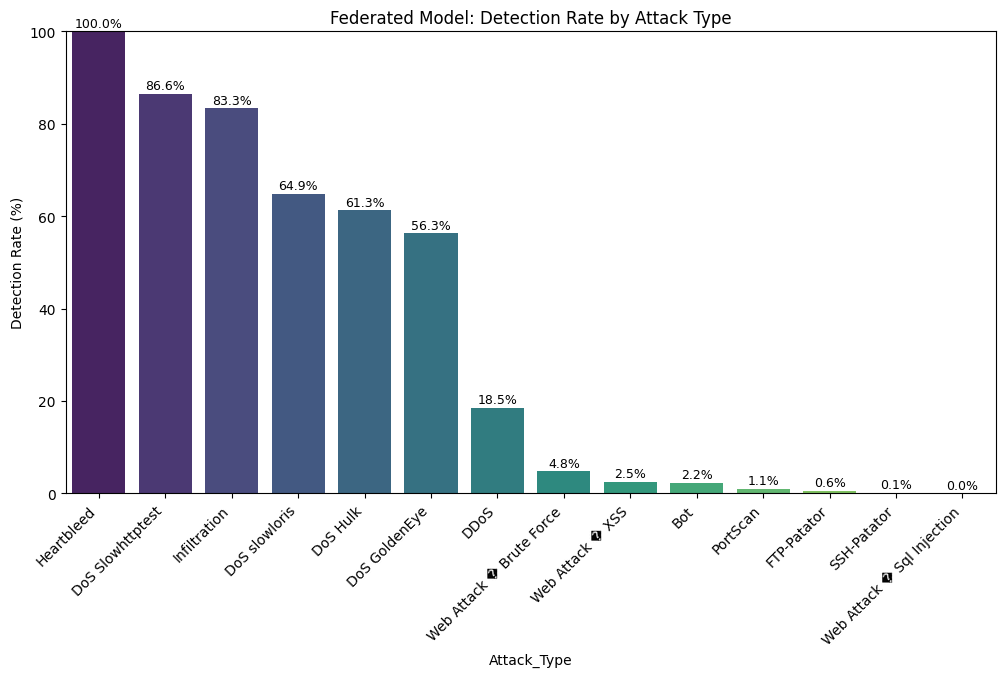

In [20]:
# Performance analysis for federated model
print("\nGenerating Attack Detection Breakdown for Federated Model...")

global_preds = [1 if e > threshold else 0 for e in global_mse]

raw_labels = [str(label).strip() for label in y_test_global]
breakdown_df = pd.DataFrame({
    'Attack_Type': raw_labels,
    'Predicted_Status': ['Detected' if p == 1 else 'Missed' for p in global_preds]
})

attack_df = breakdown_df[breakdown_df['Attack_Type'] != 'BENIGN']
detection_stats = attack_df.groupby('Attack_Type')['Predicted_Status'].value_counts(normalize=True).unstack().fillna(0)

if 'Detected' not in detection_stats.columns:
    detection_stats['Detected'] = 0.0

detection_rates = detection_stats['Detected'] * 100
detection_rates = detection_rates.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=detection_rates.index, y=detection_rates.values, palette='viridis')
plt.title("Federated Model: Detection Rate by Attack Type")
plt.ylabel("Detection Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)


for i, v in enumerate(detection_rates.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)

plt.show()